# Presentation nozzle slices: YZ

One four-panel figure per black-hole mass.

In [1]:
# ruff: noqa: E402 -- local dev path and plotting style must load before pyplot
import importlib.util
import sys
from pathlib import Path

REPO = Path("/home/hey4/rich_tde")
sys.path.insert(0, str(REPO / "dev"))

import dev  # noqa: F401 -- applies the repository plotting style
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from richio.plots import scalar_map

from dev import SNAPSHOT_TFB

## Choices

In [2]:
SELECTED_TFB = {"1e4": 1, "1e5": 1, "1e6": 1.1}
Y_CENTER_RSUN = {"1e4": 0.0, "1e5": -20.0, "1e6": -80.0}
BOX_SCALE = {"1e4": 1.0, "1e5": 1.2, "1e6": 1.2}
RESOLUTION = 768
WORKERS = 8
DPI = 240
DISSIPATION_DECADES = 4.0
FIGSIZE = (13.0, 6.5)
STREAMLINE_STYLE = {
    "color": "white",
    "density": 1.5,
    "linewidth": 0.6,
    "arrowsize": 0.8,
}
OUTPUT_DIR = REPO / "data/processed/PresentationNozzleSlices/yz"

FIELDS = (
    ("density", "Density", r"$\log_{10}(\rho/[\mathrm{g\,cm^{-3}}])$", "twilight"),
    ("pressure", "Gas pressure", r"$\log_{10}(P/[\mathrm{dyn\,cm^{-2}}])$", "rainbow"),
    (
        "temperature",
        "Gas temperature",
        r"$\log_{10}(T_\mathrm{gas}/\mathrm{K})$",
        "inferno",
    ),
    (
        "dissipation",
        "Dissipation",
        r"$\log_{10}(\dot{E}_\mathrm{diss}/[\mathrm{erg\,s^{-1}\,cm^{-3}}])$",
        "viridis",
    ),
)

# Optional per-run overrides, e.g. {"1e4": {"density": (-10, -4)}}.
COLOR_LIMIT_OVERRIDES = {"1e4": {"temperature": (5, 6.5)}, "1e5": {}, "1e6": {}}

## Data

The slice and box scale with each run's $r_p$; only the displayed axes are converted to $R_\odot$.

In [3]:
def load_script(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module


yz_batch = load_script("nozzle_yz_slices", REPO / "works/shock-tde/nozzle-yz-slices.py")

records = {}
for mode, run in enumerate(("1e4", "1e5", "1e6"), start=1):
    config = yz_batch.mode_settings(mode)
    requested_tfb = SELECTED_TFB[run]
    snapnum, snapshot_path = SNAPSHOT_TFB(run, requested_tfb)
    y_center_rsun = Y_CENTER_RSUN[run]
    box_scale = BOX_SCALE[run]
    if y_center_rsun == 0.0 and box_scale == 1.0:
        cache_path = (
            REPO
            / f"data/processed/NozzleYZSlices/{run}/grids"
            / f"nozzle_yz_snap_{snapnum:04d}_{RESOLUTION}.npz"
        )
    else:
        center_tag = f"{y_center_rsun:+g}".replace("+", "p").replace("-", "m")
        scale_tag = f"{box_scale:g}".replace(".", "p")
        cache_path = (
            OUTPUT_DIR
            / f"grids/{run}"
            / f"nozzle_yz_snap_{snapnum:04d}_{RESOLUTION}_ycenter_{center_tag}Rsun_scale_{scale_tag}.npz"
        )
    if not yz_batch.cache_complete(cache_path, RESOLUTION):
        print(f"[{run}] gridding snapshot {snapnum}", flush=True)
        yz_batch.cache_snapshot(
            snapshot_path,
            cache_path,
            config,
            RESOLUTION,
            WORKERS,
            y_center_rsun=y_center_rsun,
            box_scale=box_scale,
        )
    with np.load(cache_path) as data:
        actual_tfb = float(data["time_tfb"])
    records[run] = {
        "config": config,
        "snapnum": snapnum,
        "snapshot_path": Path(snapshot_path),
        "cache_path": cache_path,
        "requested_tfb": requested_tfb,
        "actual_tfb": actual_tfb,
        "y_center_rsun": y_center_rsun,
        "box_scale": box_scale,
    }
    print(
        f"[{run}] snapshot {snapnum}: t/t_fb={actual_tfb:.3f} "
        f"(requested {requested_tfb:.2f}), y center={y_center_rsun:g} R_sun, "
        f"box scale={box_scale:g}"
    )

[1e4] snapshot 77: t/t_fb=0.999 (requested 1.00), y center=0 R_sun, box scale=1


/tmp/ipykernel_579272/1447182973.py:15: UserWarning: Closest 1e5 snapshot is at 0.606 t_fb, which is 0.394 t_fb from the requested 1.000 t_fb
  snapnum, snapshot_path = SNAPSHOT_TFB(run, requested_tfb)


[1e5] snapshot 161: t/t_fb=0.606 (requested 1.00), y center=-20 R_sun, box scale=1.2


[1e6] snapshot 877: t/t_fb=1.099 (requested 1.10), y center=-80 R_sun, box scale=1.2


## Plot

1e4: snapshot 77, t/t_fb=0.999, y center=0 R_sun, box scale=1, /data1/projects/pi-rossiem/TDE_data/NewSnellius/R0.47M0.5BH10000beta1S60ComptonHiRes/snap_full_77.h5


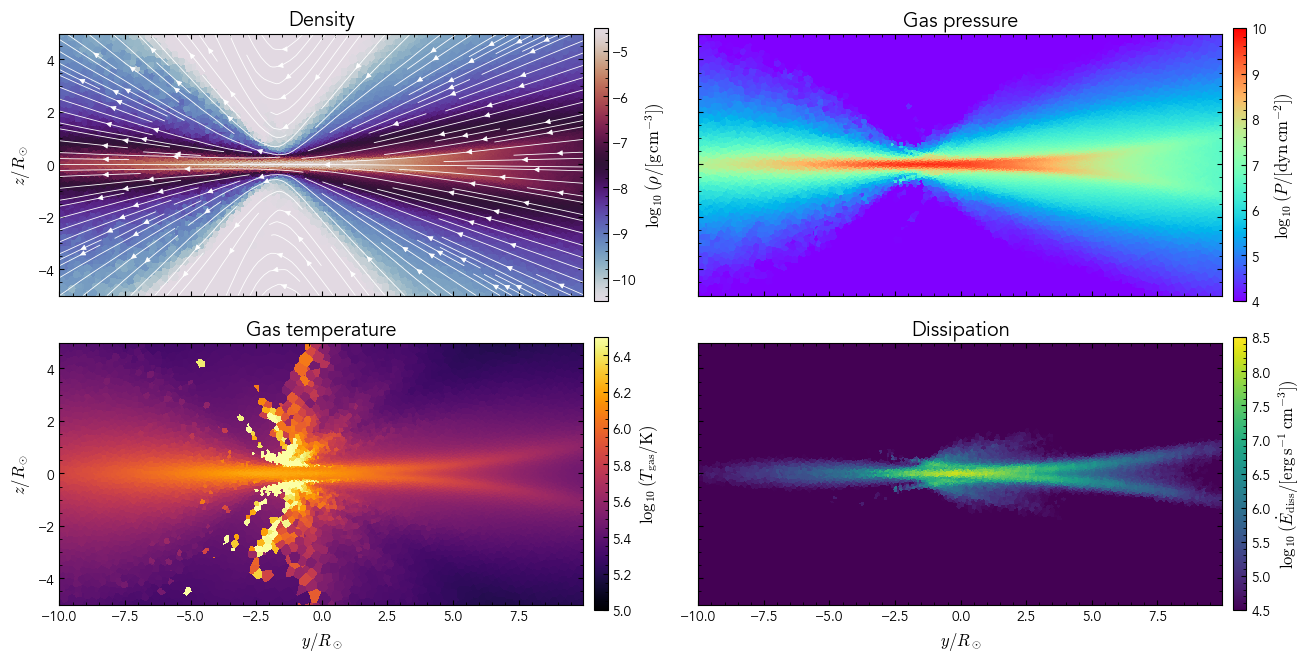

saved /home/hey4/rich_tde/data/processed/PresentationNozzleSlices/yz/nozzle_yz_1e4_snap_0077.png
1e5: snapshot 161, t/t_fb=0.606, y center=-20 R_sun, box scale=1.2, /data1/projects/pi-rossiem/TDE_data/YujieSnellius/R0.47M0.5BH100000beta1S60n1.5ComptonHiResNewAMR/snap_full_161.h5


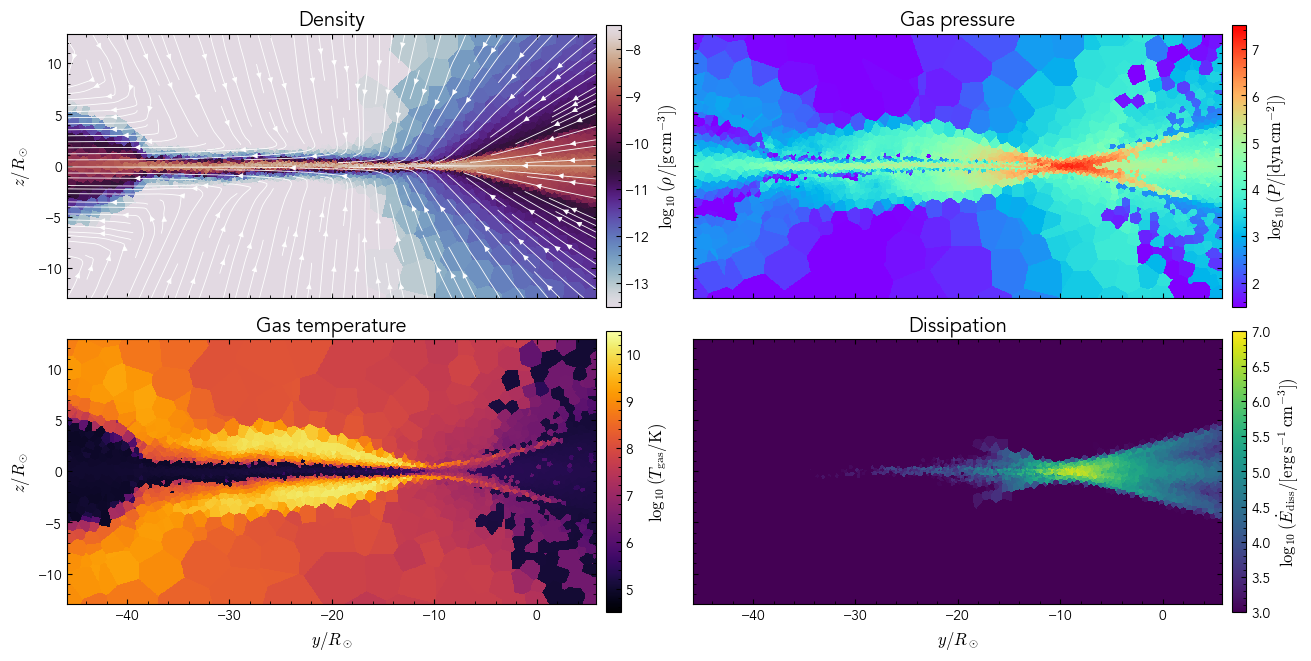

saved /home/hey4/rich_tde/data/processed/PresentationNozzleSlices/yz/nozzle_yz_1e5_snap_0161.png
1e6: snapshot 877, t/t_fb=1.099, y center=-80 R_sun, box scale=1.2, /data1/projects/pi-rossiem/TDE_data/SS24_diag/TEMPTDE4_new/snap_877.h5


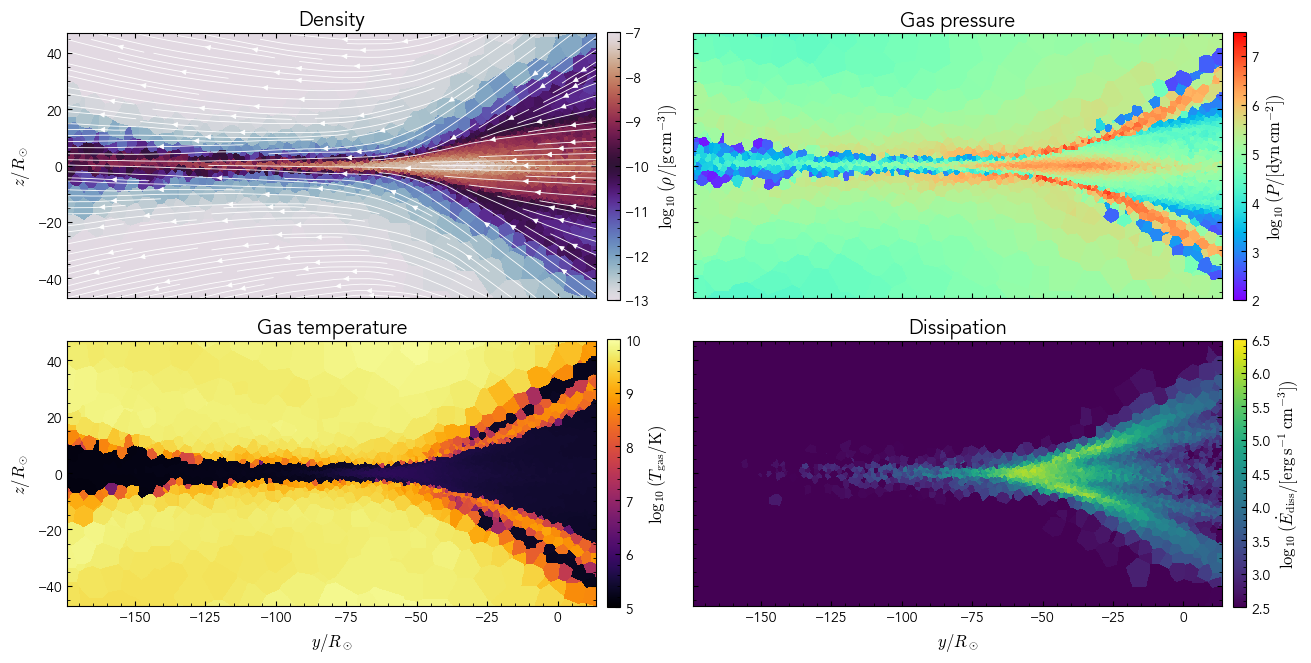

saved /home/hey4/rich_tde/data/processed/PresentationNozzleSlices/yz/nozzle_yz_1e6_snap_0877.png


In [4]:
def plot_yz(record):
    run = record["config"].run
    with np.load(record["cache_path"]) as data:
        y_rsun = np.array(data["y_rsun"])
        z_rsun = np.array(data["z_rsun"])
        grids = {name: np.array(data[name]) for name, *_ in FIELDS}
        vy = np.array(data["vy_kms"])
        vz = np.array(data["vz_stream_kms"])

    limits = yz_batch.logarithmic_limits([record["cache_path"]], yz_batch.BROAD_FIELDS)
    dissipation_vmax = limits["dissipation"][1]
    limits["dissipation"] = (dissipation_vmax - DISSIPATION_DECADES, dissipation_vmax)
    limits.update(COLOR_LIMIT_OVERRIDES[run])
    fig, axes = plt.subplots(
        2, 2, figsize=FIGSIZE, sharex=True, sharey=True, layout="constrained"
    )
    for ax, (name, title, label, cmap) in zip(axes.flat, FIELDS):
        ax.set_box_aspect(0.5)
        scalar_map(
            grids[name],
            y_rsun,
            z_rsun,
            ax=ax,
            cmap=cmap,
            colorbar_label=label,
            log_scale=False,
            vmin=limits[name][0],
            vmax=limits[name][1],
            aspect_equal=False,
            colorbar_pad=0.02,
            shading="auto",
            rasterized=True,
        )
        ax.set_title(title)
        ax.set_xlim(float(y_rsun[0]), float(y_rsun[-1]))
        ax.set_ylim(float(z_rsun[0]), float(z_rsun[-1]))
        if name == "density":
            ax.streamplot(y_rsun, z_rsun, vy.T, vz.T, **STREAMLINE_STYLE)
    for ax in axes[-1]:
        ax.set_xlabel(r"$y/R_\odot$")
    for ax in axes[:, 0]:
        ax.set_ylabel(r"$z/R_\odot$")
    return fig


OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for run, record in records.items():
    print(
        f"{run}: snapshot {record['snapnum']}, "
        f"t/t_fb={record['actual_tfb']:.3f}, "
        f"y center={record['y_center_rsun']:g} R_sun, "
        f"box scale={record['box_scale']:g}, {record['snapshot_path']}"
    )
    fig = plot_yz(record)
    output = OUTPUT_DIR / f"nozzle_yz_{run}_snap_{record['snapnum']:04d}.png"
    fig.savefig(output, dpi=DPI)
    display(fig)
    plt.close(fig)
    print(f"saved {output}")